<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/results_graphshow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import files
from google.colab import drive
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

In [4]:
# Google Driveをマウント
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/16-research/99_Sotsuron/results_HS01-10_28_80_84_85.xlsx'

Mounted at /content/drive


In [7]:
# ExcelファイルをPandasデータフレームに読み込む
df = pd.read_excel(file_path)

# データフレームを確認
df.head()

,HS,Year,Flow to USA,Direct Export Ratio,Direct Export Amount form China to USA,Indirect to Direct Ratio,China's Total FOB Value in G,China's Total Export Volume in subgraph,Estimated Final Flow to USA,Direct Export Amount form China to USA Growth Rate (%),China's Total FOB Value in G Growth Rate (%),China's Total Export Volume in subgraph Growth Rate (%)
0,1,1995,0.003203,0.003200,1608935,0.000934,1006344452,502784546,1.610438e+06,0.000000,0.000000,0.000000
1,1,1996,0.002998,0.002997,1457594,0.000204,973074850,486300100,1.457891e+06,-9.406284,-3.305986,-3.278630
2,1,1997,0.001857,0.001853,880888,0.001981,951802352,475303267,8.826333e+05,-39.565613,-2.186111,-2.261326
3,1,1998,0.001953,0.001951,859137,0.001101,882021558,440306891,8.600829e+05,-2.469213,-7.331437,-7.362957
4,1,1999,0.002785,0.002781,1069889,0.001429,770307502,384728051,1.071418e+06,24.530663,-12.665683,-12.622750


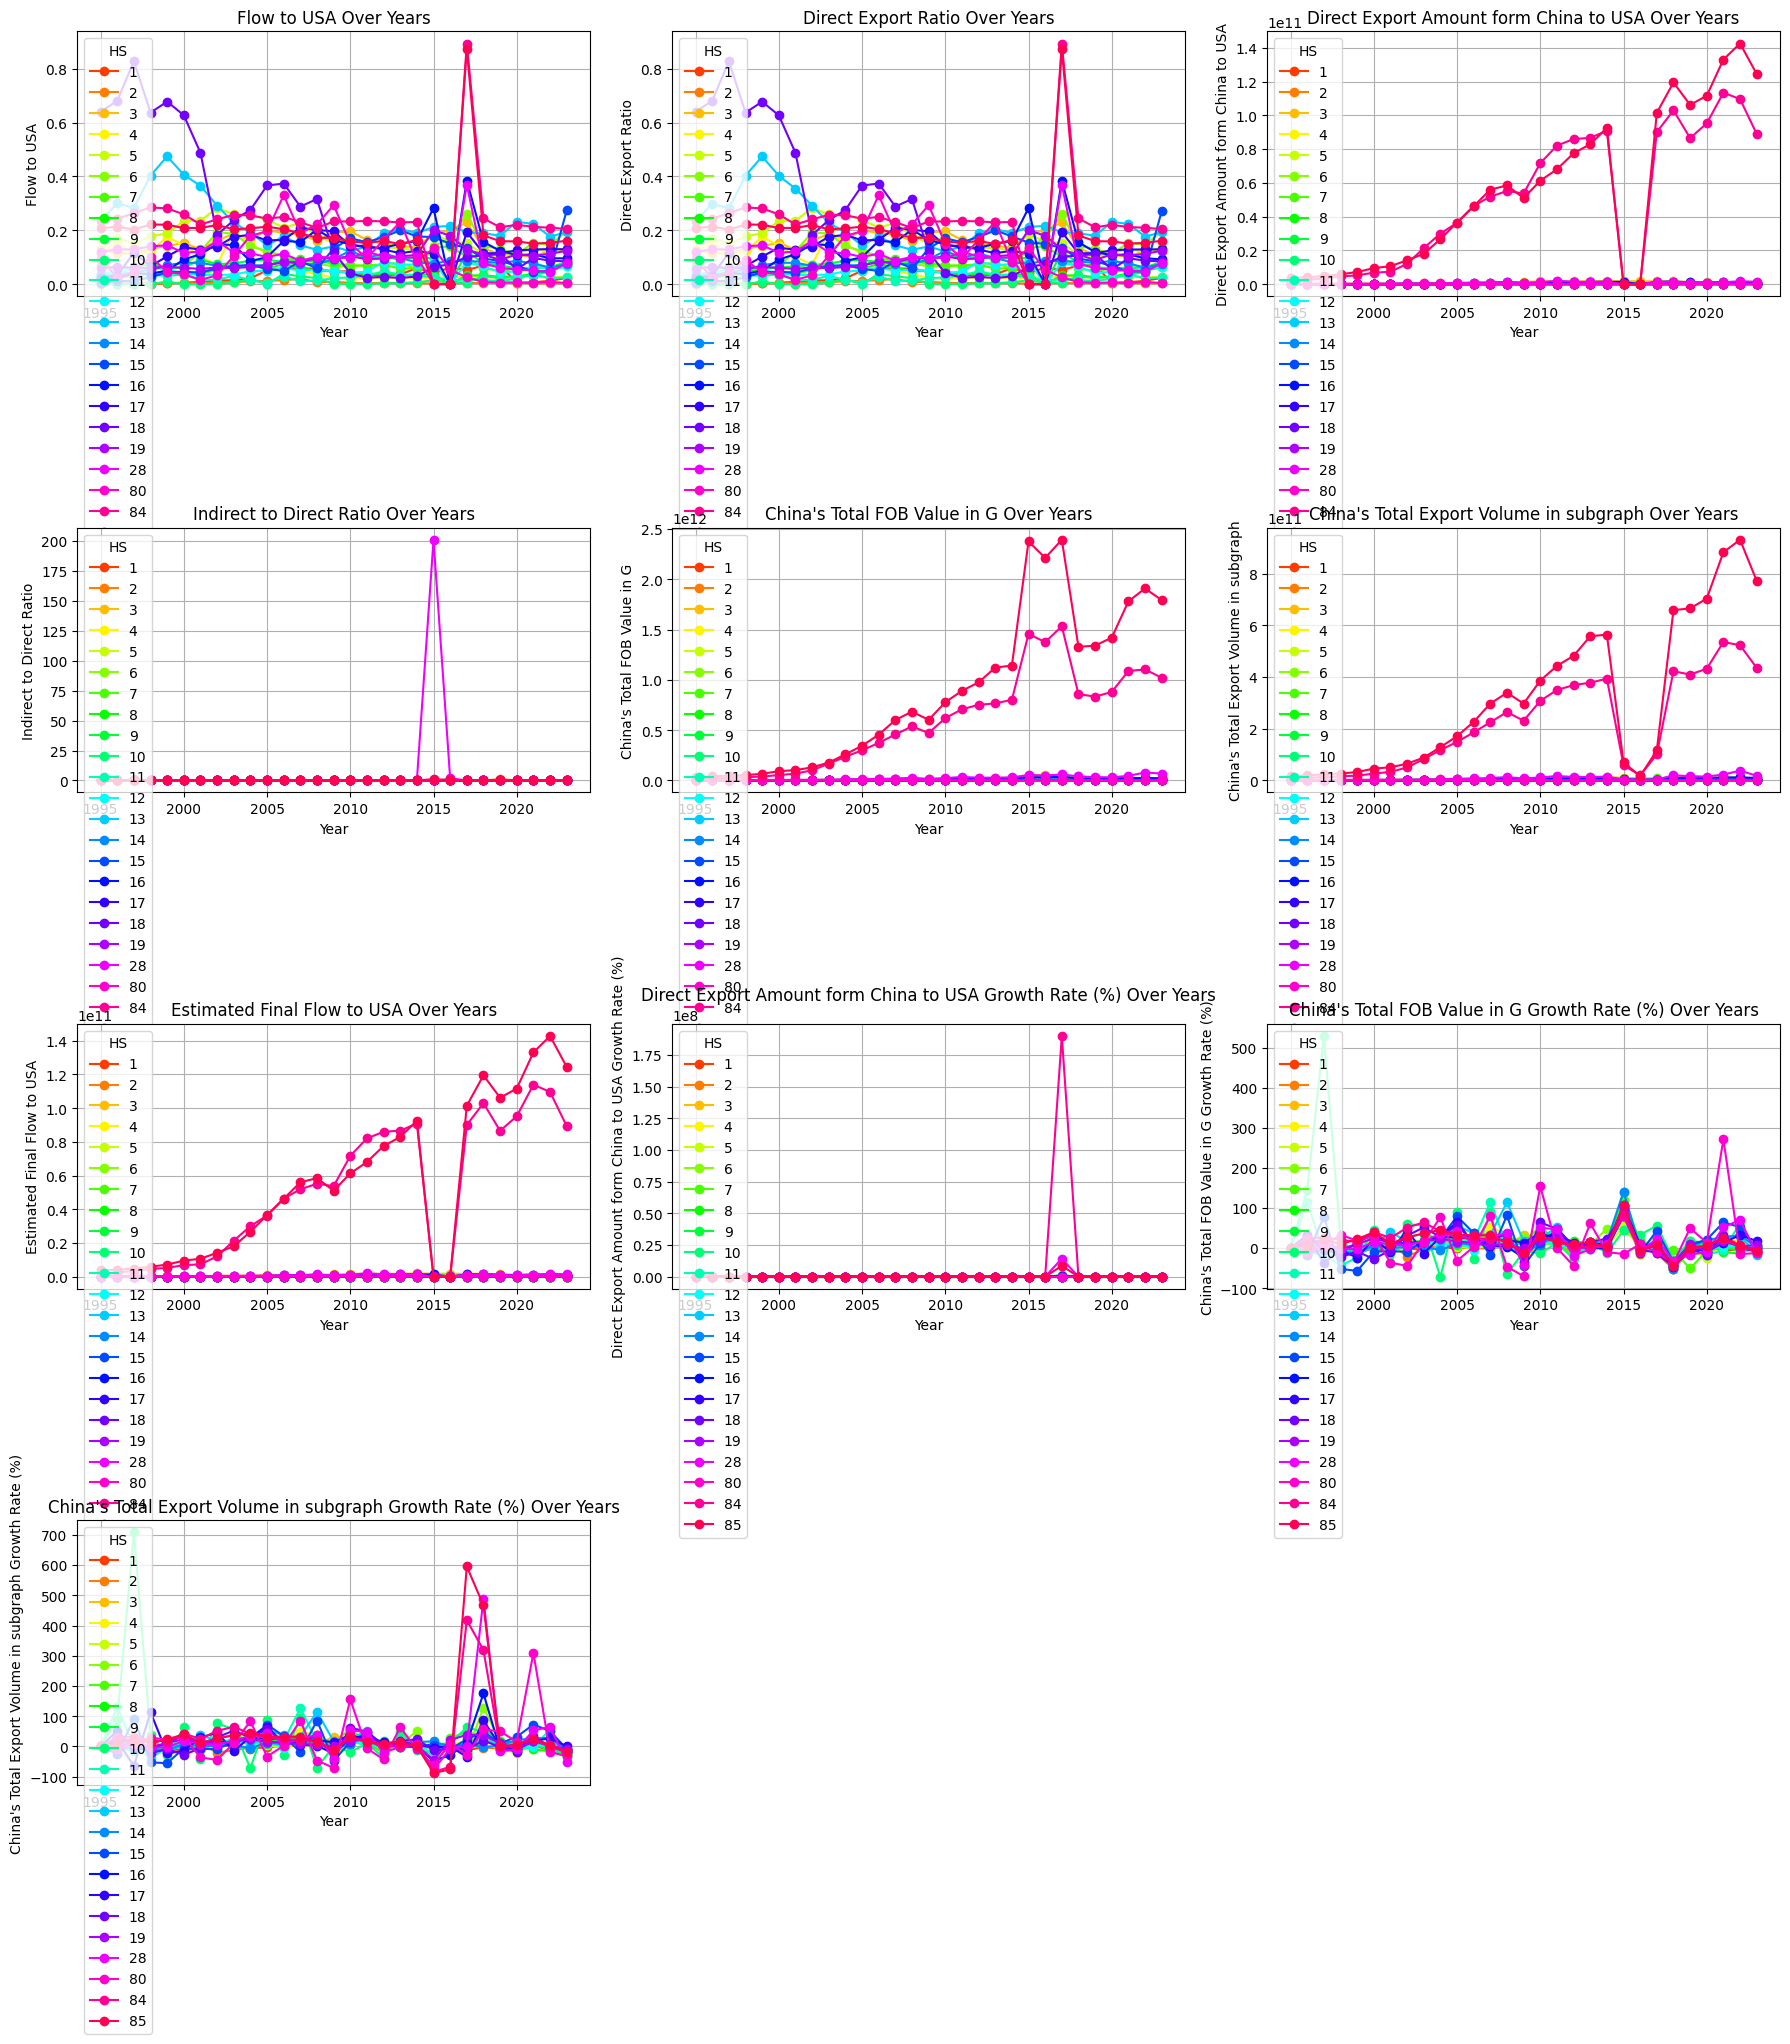

In [11]:
# 折れ線グラフを作成するカラム
columns_to_plot = [
    "Flow to USA", "Direct Export Ratio", "Direct Export Amount form China to USA",
    "Indirect to Direct Ratio", "China's Total FOB Value in G",
    "China's Total Export Volume in subgraph", "Estimated Final Flow to USA",
    "Direct Export Amount form China to USA Growth Rate (%)",
    "China's Total FOB Value in G Growth Rate (%)",
    "China's Total Export Volume in subgraph Growth Rate (%)"
]

# HSでグループ化
hs_groups = df.groupby("HS")

# カラーパレットを作成
palette = sns.color_palette("hsv", len(hs_groups))
color_map = {hs: color for hs, color in zip(hs_groups.groups.keys(), palette)}

# 横並びで表示するための設定
num_columns = 3  # 1行に表示するグラフの数
num_rows = -(-len(columns_to_plot) // num_columns)  # 必要な行数を計算（切り上げ）
fig, axes = plt.subplots(num_rows, num_columns, figsize=(18, 5 * num_rows))
axes = axes.flatten()

# グラフをプロット
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    for hs, group in hs_groups:
        ax.plot(group["Year"], group[column], marker='o', label=f'{hs}', color=color_map[hs])
    ax.set_xlabel("Year")
    ax.set_ylabel(column)
    ax.set_title(f"{column} Over Years")
    ax.legend(title="HS", loc="best")
    ax.grid(True)

# 不要なサブプロットを削除
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [28]:
# 折れ線グラフを作成するカラム
columns_to_plot = [
    "Flow to USA", "Direct Export Ratio", "Direct Export Amount form China to USA",
    "Indirect to Direct Ratio", "China's Total FOB Value in G",
    "China's Total Export Volume in subgraph", "Estimated Final Flow to USA",
    "Direct Export Amount form China to USA Growth Rate (%)",
    "China's Total FOB Value in G Growth Rate (%)",
    "China's Total Export Volume in subgraph Growth Rate (%)"
]

# HSでグループ化
hs_groups = df.groupby("HS")

# サブプロットを作成
fig = sp.make_subplots(
    rows=len(hs_groups),
    cols=len(columns_to_plot),
    shared_xaxes=True,
    shared_yaxes=False,
    horizontal_spacing=0.02,
    vertical_spacing=0.02,
    subplot_titles=[f"{column}" for column in columns_to_plot for _ in hs_groups.groups]
)

# グラフをプロット
row_idx = 1
for hs, group in hs_groups:
    for col_idx, column in enumerate(columns_to_plot, start=1):
        fig.add_trace(
            go.Scatter(
                x=group["Year"],
                y=group[column],
                mode="lines+markers",
                name=f"{hs} - {column}"
            ),
            row=row_idx,
            col=col_idx
        )
    row_idx += 1

# レイアウト調整
fig.update_layout(
    title="Matrix Format: HS vs Metrics Over Years",
    height=300 * len(hs_groups),
    width=300 * len(columns_to_plot),
    showlegend=False,
    margin=dict(l=50, r=50, t=50, b=50),
)

# グラフを表示
fig.show()

In [36]:
# 折れ線グラフを作成するカラム
columns_to_plot = [
    "Direct Export Ratio", "Direct Export Amount form China to USA",
    "Indirect to Direct Ratio", "China's Total FOB Value in G",
    "China's Total Export Volume in subgraph", "Estimated Final Flow to USA",
    "Direct Export Amount form China to USA Growth Rate (%)",
    "China's Total FOB Value in G Growth Rate (%)",
    "China's Total Export Volume in subgraph Growth Rate (%)"
]

# HSでグループ化
hs_groups = df.groupby("HS")

# サブプロットを作成
fig = sp.make_subplots(
    rows=len(hs_groups),
    cols=len(columns_to_plot),
    shared_xaxes=True,
    shared_yaxes=False,
    horizontal_spacing=0.02,
    vertical_spacing=0.02,
    subplot_titles=[f"{column}" for column in columns_to_plot for _ in hs_groups.groups]
)

# グラフをプロット
row_idx = 1
for hs, group in hs_groups:
    for col_idx, column in enumerate(columns_to_plot, start=1):
        fig.add_trace(
            go.Scatter(
                x=group["Year"],
                y=group[column],
                mode="lines+markers",
                name=f"{hs} - {column}"
            ),
            row=row_idx,
            col=col_idx
        )
    row_idx += 1

# レイアウト調整
fig.update_layout(
    title="Matrix Format: HS vs Metrics Over Years",
    height=300 * len(hs_groups),
    width=300 * len(columns_to_plot),
    showlegend=False,
    margin=dict(l=50, r=50, t=50, b=50),
    font=dict(size=10),  # フォントサイズを調整
)

# サブプロットタイトルのフォントサイズを小さくする
for annotation in fig.layout.annotations:
    annotation.font.size = 8

fig.show()


In [43]:
# 折れ線グラフを作成するカラム
columns_to_plot = [
    "Direct Export Ratio", "Direct Export Amount form China to USA",
    "Indirect to Direct Ratio", "China's Total FOB Value in G",
    "China's Total Export Volume in subgraph", "Estimated Final Flow to USA",
    "Direct Export Amount form China to USA Growth Rate (%)",
    "China's Total FOB Value in G Growth Rate (%)",
    "China's Total Export Volume in subgraph Growth Rate (%)"
]

# HSでグループ化
hs_groups = df.groupby("HS")

# サブプロットを作成（カラムを縦軸、HSを横軸に）
fig = sp.make_subplots(
    rows=len(columns_to_plot),
    cols=len(hs_groups),
    shared_xaxes=True,
    shared_yaxes=False,
    horizontal_spacing=0.01,  # 横方向の間隔を縮小
    vertical_spacing=0.02,
    subplot_titles=[f"{column}" for column in columns_to_plot for _ in hs_groups.groups]
)

# グラフをプロット
row_idx = 1
for row_idx, column in enumerate(columns_to_plot, start=1):
    col_idx = 1
    for hs, group in hs_groups:
        fig.add_trace(
            go.Scatter(
                x=group["Year"],
                y=group[column],
                mode="lines+markers",
                name=f"{hs} - {column}"
            ),
            row=row_idx,
            col=col_idx
        )
        col_idx += 1

# レイアウト調整
fig.update_layout(
    title="Matrix Format: Metrics vs HS Over Years",
    height=300 * len(columns_to_plot),
    width=400 * len(hs_groups),  # 横幅を拡大
    showlegend=False,
    margin=dict(l=50, r=50, t=50, b=50),
    font=dict(size=10),  # フォントサイズを調整
)

# サブプロットタイトルのフォントサイズを小さくする
for annotation in fig.layout.annotations:
    annotation.font.size = 10

fig.show()


In [47]:
# 折れ線グラフを作成するカラム
columns_to_plot = [
    "Direct Export Ratio", "Direct Export Amount form China to USA",
    "Indirect to Direct Ratio", "China's Total FOB Value in G",
    "China's Total Export Volume in subgraph", "Estimated Final Flow to USA",
    "Direct Export Amount form China to USA Growth Rate (%)",
    "China's Total FOB Value in G Growth Rate (%)",
    "China's Total Export Volume in subgraph Growth Rate (%)"
]

# HSでグループ化
hs_groups = df.groupby("HS")

# サブプロットを作成（カラムを縦軸、HSを横軸に）
fig = sp.make_subplots(
    rows=len(columns_to_plot),
    cols=len(hs_groups),
    shared_xaxes=True,
    shared_yaxes=False,
    horizontal_spacing=0.01,  # 横方向の間隔を縮小
    vertical_spacing=0.02,
    subplot_titles=[f"{column} (HS: {hs})" for column in columns_to_plot for hs in hs_groups.groups]
)

# グラフをプロット
row_idx = 1
for row_idx, column in enumerate(columns_to_plot, start=1):
    col_idx = 1
    for hs, group in hs_groups:
        fig.add_trace(
            go.Scatter(
                x=group["Year"],
                y=group[column],
                mode="lines+markers",
                name=f"{column}"
            ),
            row=row_idx,
            col=col_idx
        )
        col_idx += 1

# レイアウト調整
fig.update_layout(
    title="Matrix Format: Metrics vs HS Over Years",
    height=300 * len(columns_to_plot),
    width=400 * len(hs_groups),  # 横幅を拡大
    showlegend=False,
    margin=dict(l=100, r=50, t=100, b=50),
    font=dict(size=10),  # フォントサイズを調整
)

# サブプロットタイトルのフォントサイズを小さくする
for annotation in fig.layout.annotations:
    annotation.font.size = 8

fig.show()
